# Weather Classification Project
## AdaBoost (Adaptive Boosting) — Full Analysis

---
**Algorithm:** AdaBoost (Adaptive Boosting)  
**Date:** 2025  
**Description:** End-to-end weather classification using AdaBoost with comprehensive EDA and visualizations.

---

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False

# Machine learning - preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve

# Machine learning - models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Machine learning - metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support, roc_auc_score,
    ConfusionMatrixDisplay
)

from math import pi
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv('weather_classification_data.csv')

print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
df.head(10)

DATASET OVERVIEW
Shape          : 13,200 rows × 11 columns
Memory usage   : 3602.1 KB



,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


## 3. Exploratory Data Analysis (EDA)
### 3.1 Data Structure and Quality

In [3]:
print('DATA TYPES & NON-NULL COUNTS')
print('-'*60)
df.info()

DATA TYPES & NON-NULL COUNTS
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [4]:
print('MISSING VALUES')
print('-'*60)
missing = df.isna().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

if missing.sum() > 0:
    df = df.dropna()
    print(f'Rows after dropping NaN: {df.shape[0]:,}')

MISSING VALUES
------------------------------------------------------------
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Total missing values: 0


In [5]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'After removing duplicates: {df.shape[0]:,} rows')

Duplicate rows: 0


In [6]:
print('STATISTICAL SUMMARY')
print('-'*60)
df.describe().T.round(3)

STATISTICAL SUMMARY
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Temperature,13200.0,19.128,17.386,-25.00,4.0,21.00,31.000,109.00
Humidity,13200.0,68.711,20.194,20.00,57.0,70.00,84.000,109.00
Wind Speed,13200.0,9.832,6.909,0.00,5.0,9.00,13.500,48.50
Precipitation (%),13200.0,53.644,31.947,0.00,19.0,58.00,82.000,109.00
Atmospheric Pressure,13200.0,1005.828,37.200,800.12,994.8,1007.65,1016.772,1199.21
UV Index,13200.0,4.006,3.857,0.00,1.0,3.00,7.000,14.00
Visibility (km),13200.0,5.463,3.371,0.00,3.0,5.00,7.500,20.00


In [7]:
# Drop Humidity if present (consistent with original project)
if 'Humidity' in df.columns:
    df = df.drop(columns=['Humidity'])
    print('Humidity column removed.')

print(f'Current columns: {list(df.columns)}')

Humidity column removed.
Current columns: ['Temperature', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']


In [8]:
print('TARGET CLASS DISTRIBUTION')
print('-'*60)
print(df['Weather Type'].value_counts())
print('\nSEASON DISTRIBUTION')
print('-'*60)
print(df['Season'].value_counts())
print('\nLOCATION DISTRIBUTION')
print('-'*60)
print(df['Location'].value_counts())

TARGET CLASS DISTRIBUTION
------------------------------------------------------------
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

SEASON DISTRIBUTION
------------------------------------------------------------
Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64

LOCATION DISTRIBUTION
------------------------------------------------------------
Location
inland      4816
mountain    4813
coastal     3571
Name: count, dtype: int64


### 3.2 Data Visualizations

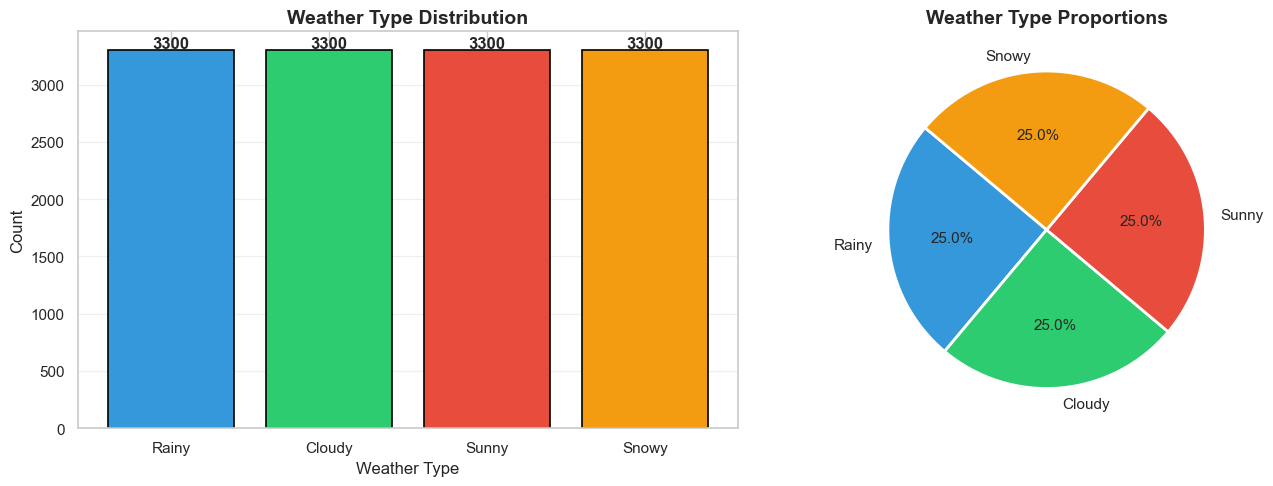

In [9]:
# ── Target class distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_counts = df['Weather Type'].value_counts()
colors_main = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

axes[0].bar(weather_counts.index, weather_counts.values, color=colors_main, edgecolor='black', linewidth=1.2)
for i, (label, val) in enumerate(weather_counts.items()):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Weather Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Weather Type')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%',
            colors=colors_main, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Weather Type Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

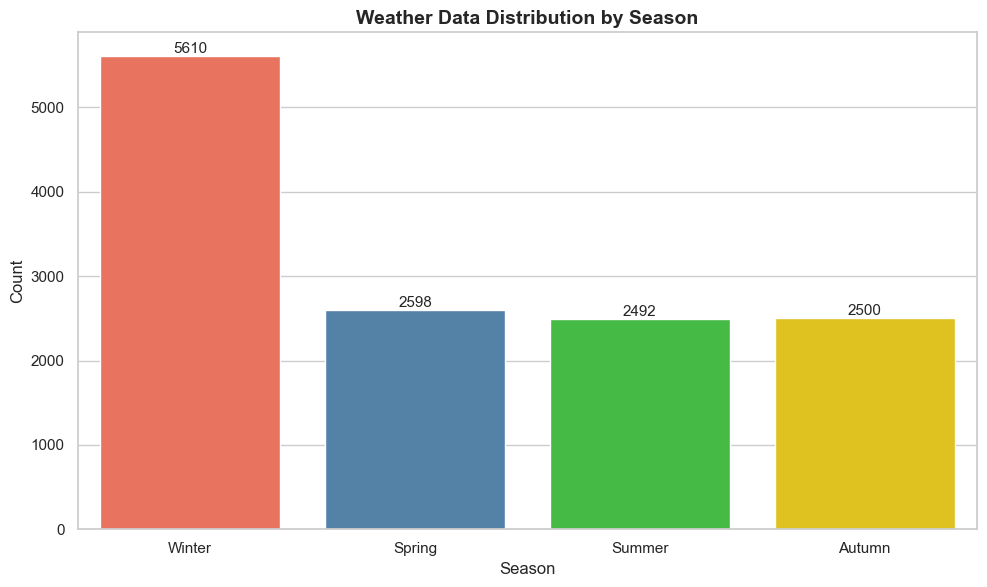

In [10]:
# ── Seasonal distribution ──────────────────────────────────────────
season_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Season', hue='Season', palette=season_palette, legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Weather Data Distribution by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

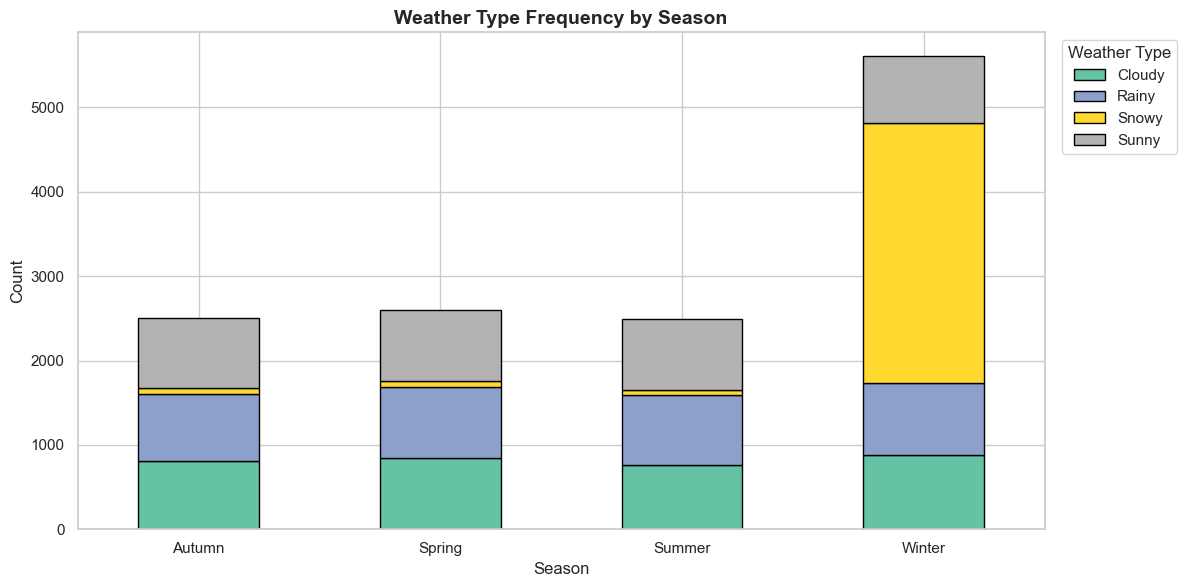

In [11]:
# ── Weather type per season (stacked bar) ──────────────────────────
cross_tab = pd.crosstab(df['Season'], df['Weather Type'])
cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2', edgecolor='black')
plt.title('Weather Type Frequency by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Weather Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

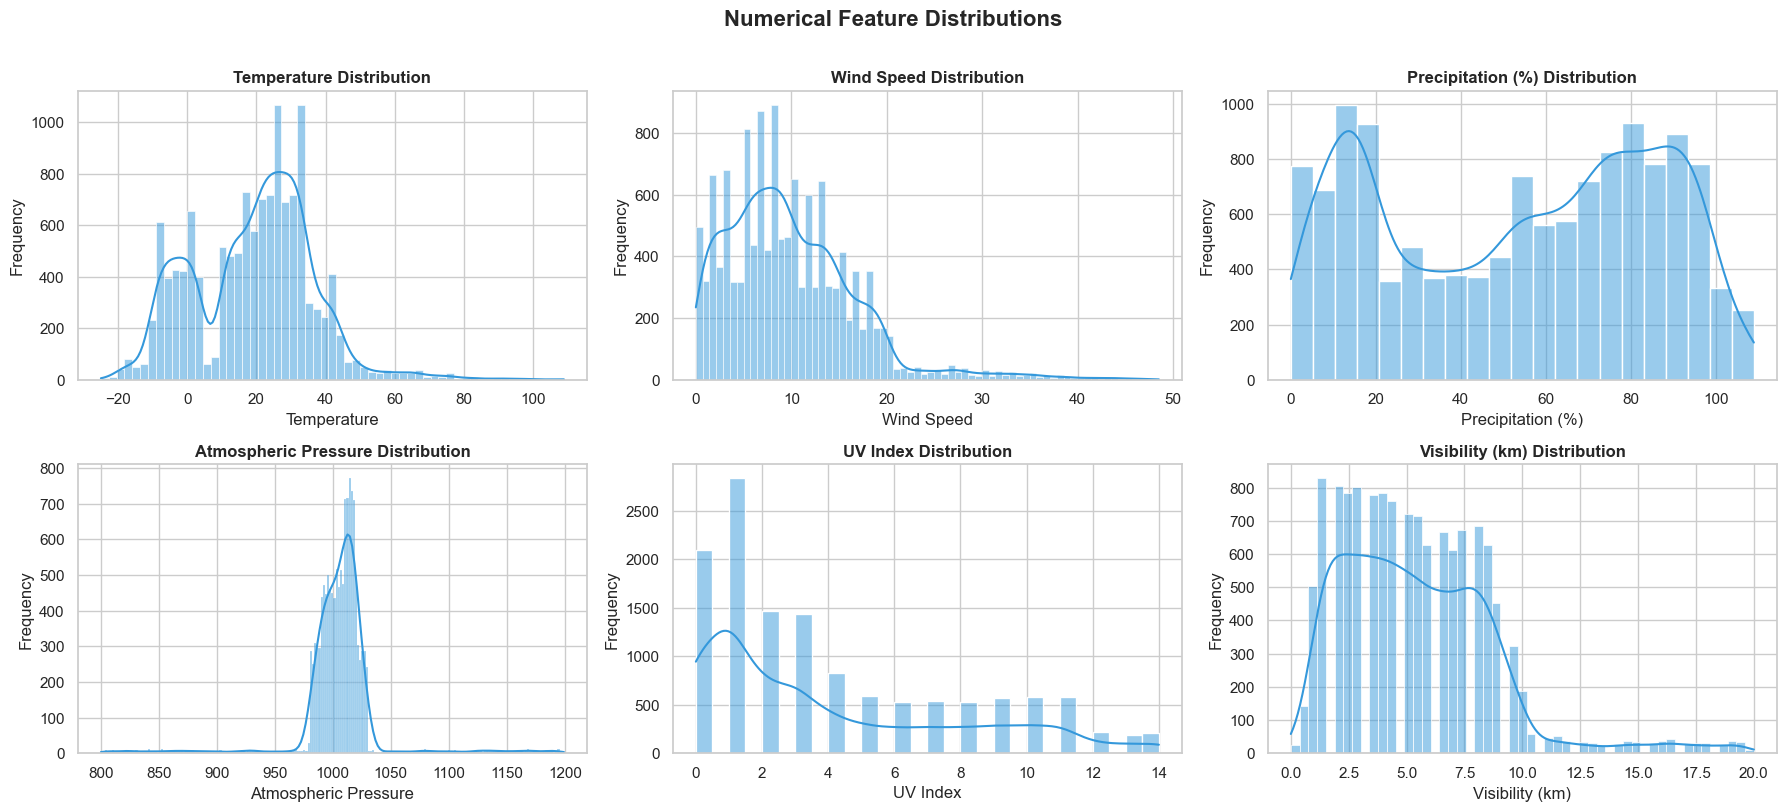

In [12]:
# ── Numerical feature distributions ───────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#3498db', edgecolor='white')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

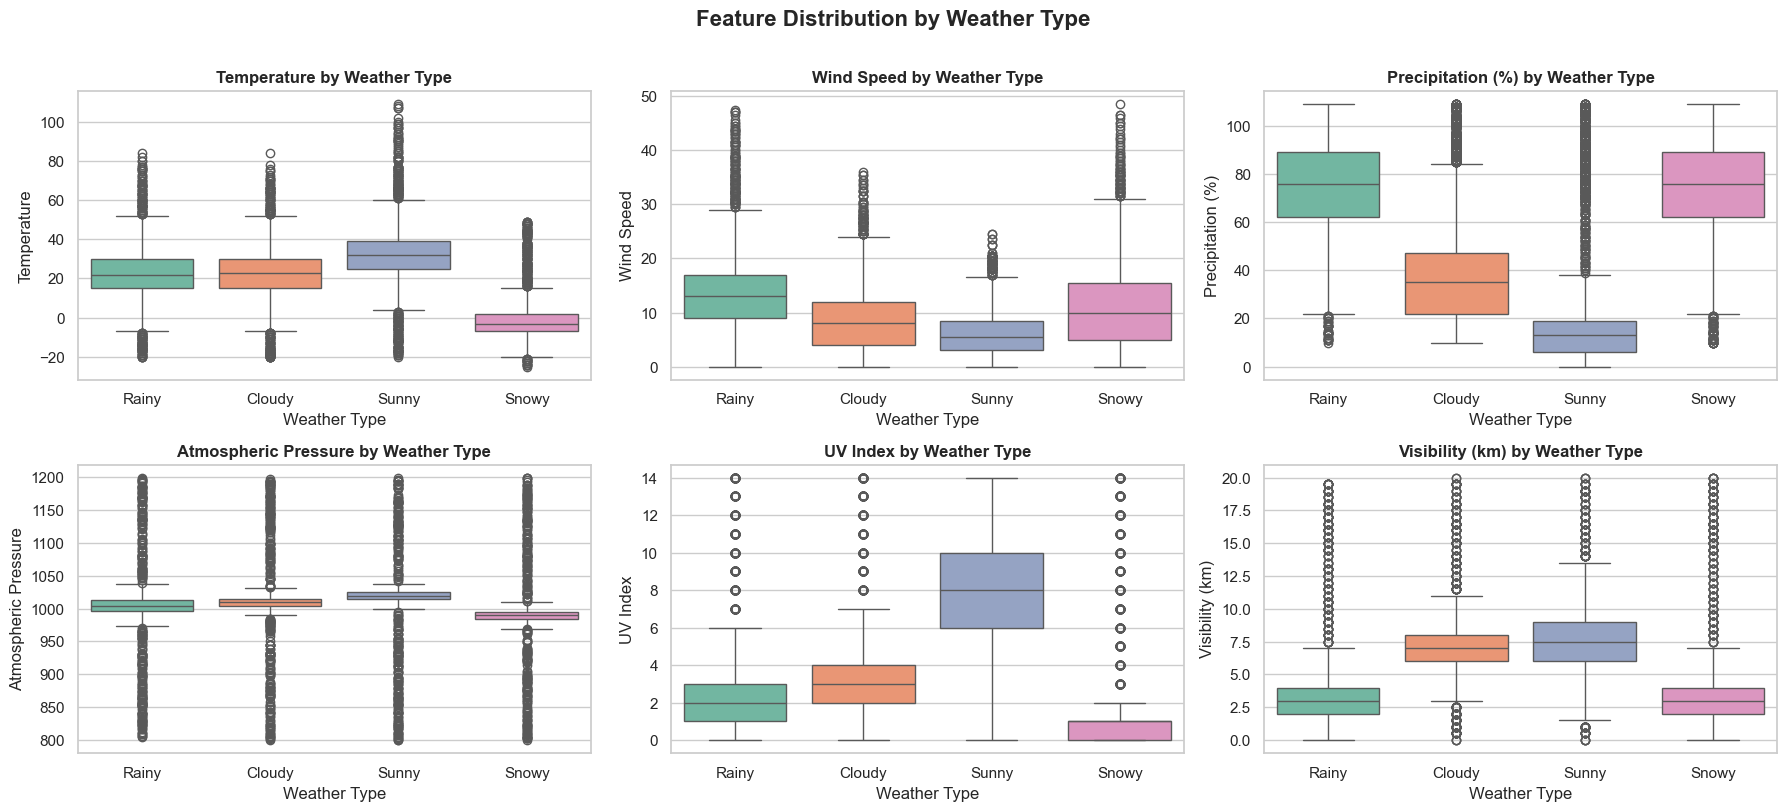

In [13]:
# ── Box plots: numerical features by weather type ──────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Weather Type', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Weather Type', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Weather Type')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution by Weather Type', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

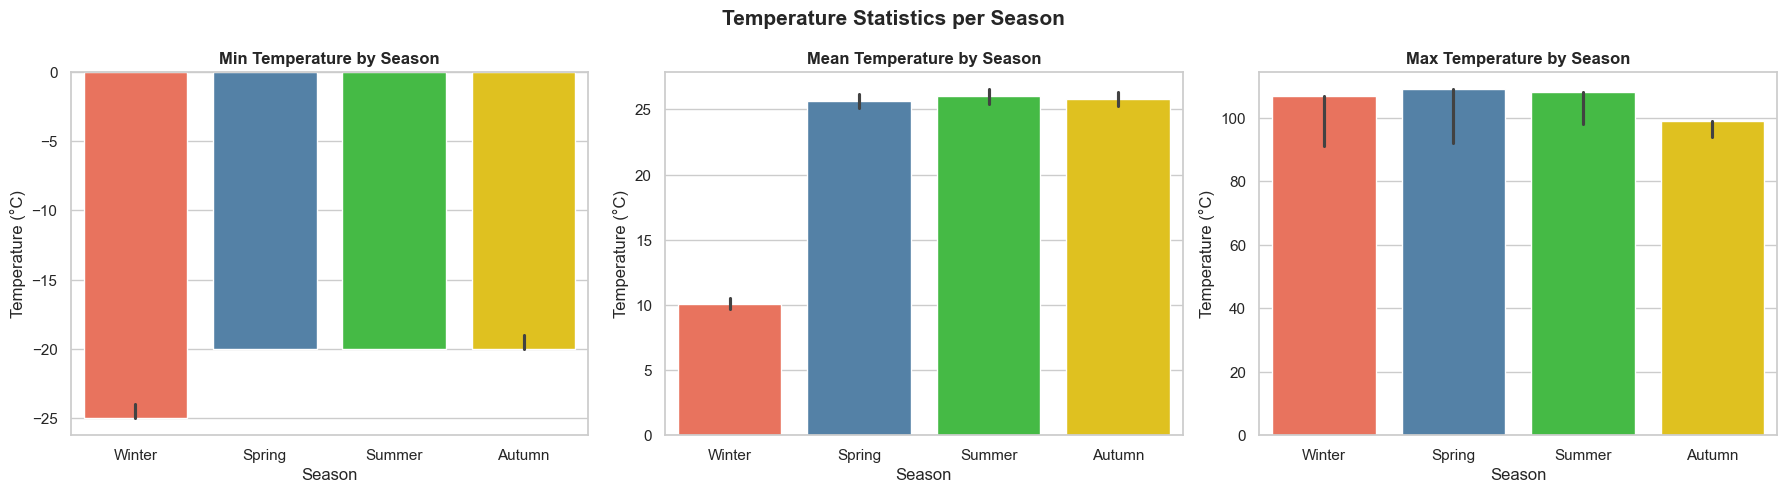

In [14]:
# ── Temperature statistics by season ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, stat in enumerate(['min', 'mean', 'max']):
    sns.barplot(data=df, x='Season', y='Temperature', hue='Season',
                palette=season_palette, estimator=stat, ax=axes[idx], legend=False)
    axes[idx].set_title(f'{stat.capitalize()} Temperature by Season', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Season')
    axes[idx].set_ylabel('Temperature (°C)')

plt.suptitle('Temperature Statistics per Season', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

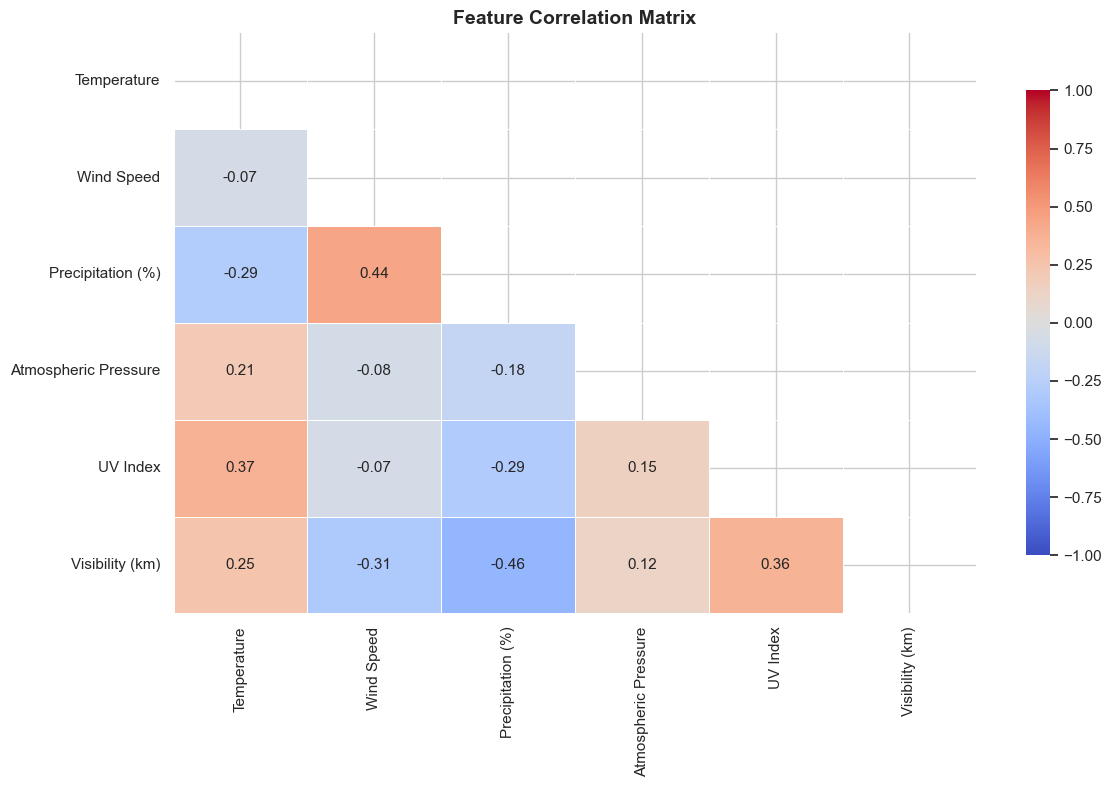

In [15]:
# ── Correlation heatmap ────────────────────────────────────────────
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

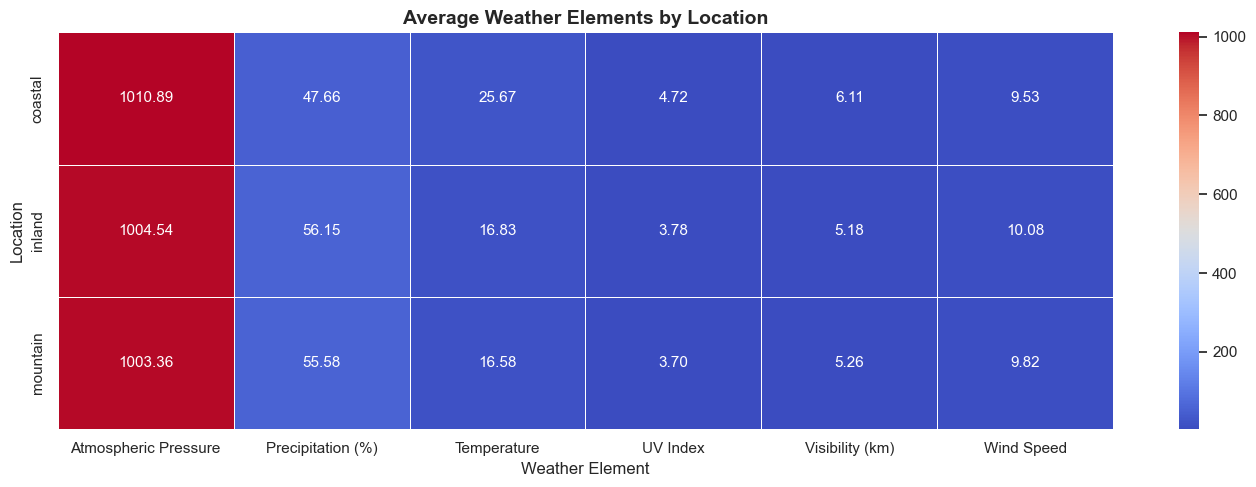

In [16]:
# ── Heatmap: average weather elements by location ─────────────────
heatmap_data = df.pivot_table(index='Location', values=numeric_cols, aggfunc='mean')

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Average Weather Elements by Location', fontsize=14, fontweight='bold')
plt.xlabel('Weather Element')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

In [17]:
# ── Scatter: Temperature vs Wind Speed by Season ──────────────────
if PLOTLY_AVAILABLE:
    fig = px.scatter(df, x='Temperature', y='Wind Speed', color='Season',
                     hover_name='Location', size='Precipitation (%)',
                     title='Temperature vs Wind Speed (by Season & Precipitation)')
    fig.update_layout(height=500)
    fig.show()
else:
    plt.figure(figsize=(10, 6))
    for season in df['Season'].unique():
        subset = df[df['Season'] == season]
        plt.scatter(subset['Temperature'], subset['Wind Speed'],
                    label=season, alpha=0.5, s=30)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Wind Speed')
    plt.title('Temperature vs Wind Speed by Season')
    plt.legend()
    plt.tight_layout()
    plt.show()

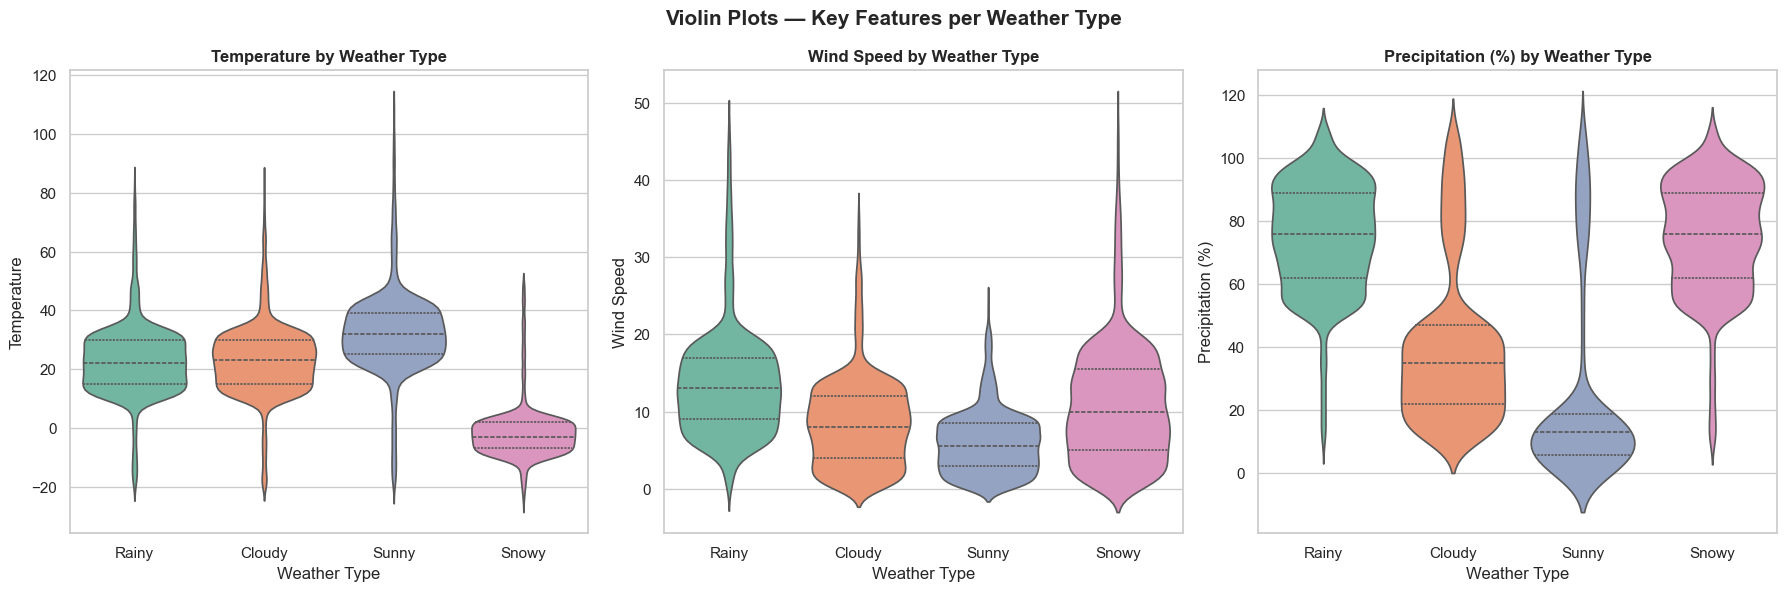

In [18]:
# ── Violin plot: key features by weather type ─────────────────────
key_features = ['Temperature', 'Wind Speed', 'Precipitation (%)']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feat in enumerate(key_features):
    sns.violinplot(data=df, x='Weather Type', y=feat, palette='Set2',
                   inner='quartile', ax=axes[i])
    axes[i].set_title(f'{feat} by Weather Type', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Weather Type')

plt.suptitle('Violin Plots — Key Features per Weather Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

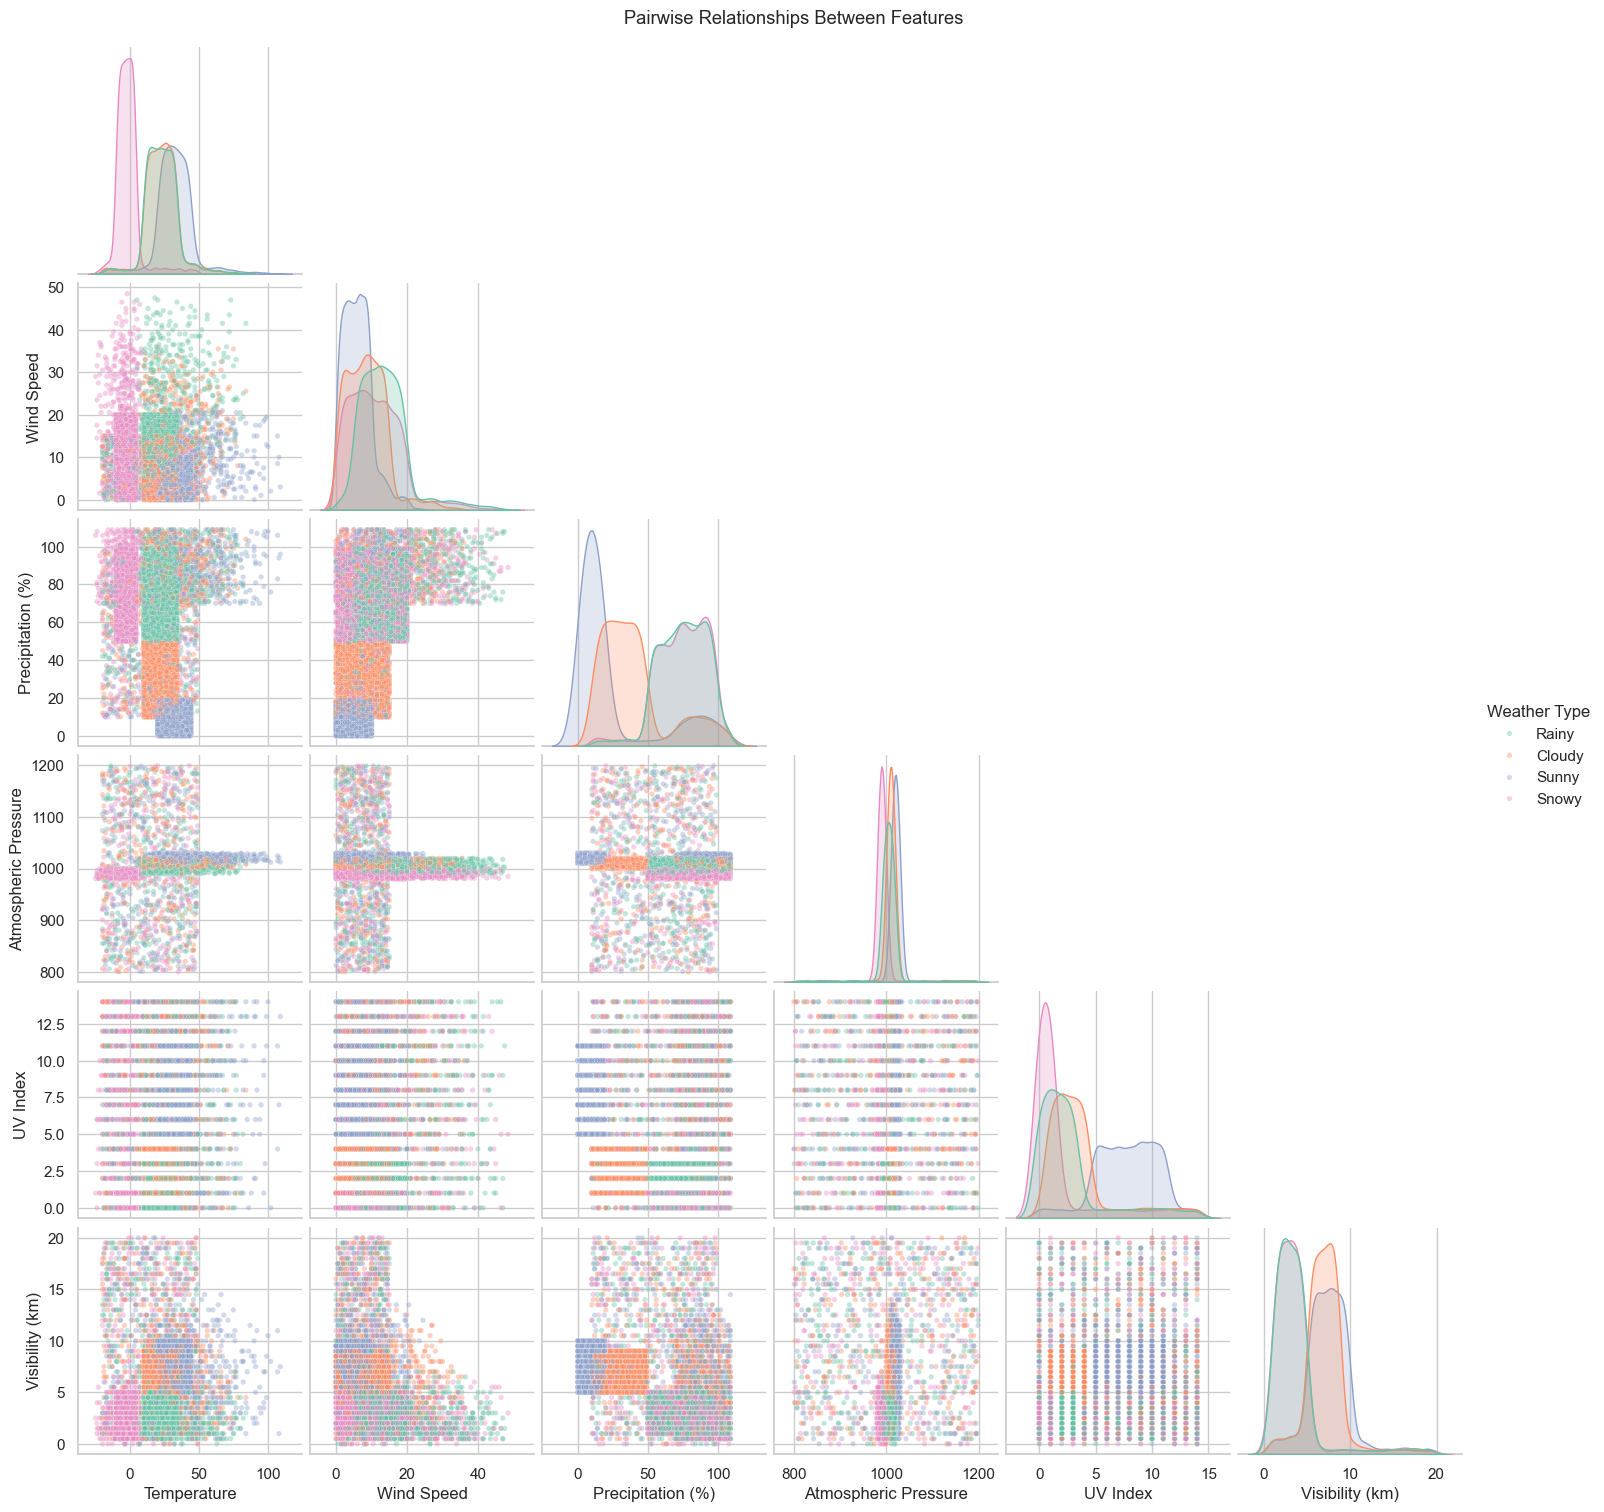

In [19]:
# ── Pairplot ───────────────────────────────────────────────────────
sns.pairplot(df[numeric_cols + ['Weather Type']], hue='Weather Type',
             palette='Set2', corner=True, plot_kws=dict(alpha=0.4, s=15))
plt.suptitle('Pairwise Relationships Between Features', y=1.01)
plt.show()

## 4. Data Preprocessing

In [20]:
TARGET_COL = 'Weather Type'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_feature_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'Features shape    : {X.shape}')
print(f'Target shape      : {y.shape}')
print(f'Numeric features  : {numeric_feature_cols}')
print(f'Categorical features: {categorical_cols}')
print(f'\nClass distribution:\n{y.value_counts()}')

Features shape    : (13200, 9)
Target shape      : (13200,)
Numeric features  : ['Temperature', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Categorical features: ['Cloud Cover', 'Season', 'Location']

Class distribution:
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


In [21]:
# Pipeline for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_feature_cols),
    ('cat', categorical_transformer, categorical_cols),
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples  : {X_train.shape[0]:,}')
print(f'Testing samples   : {X_test.shape[0]:,}')
print(f'\nTraining class distribution:')
print(y_train.value_counts())

Training samples  : 10,560
Testing samples   : 2,640

Training class distribution:
Weather Type
Snowy     2640
Sunny     2640
Rainy     2640
Cloudy    2640
Name: count, dtype: int64


## 5. AdaBoost Model
### 5.1 Build and Train

In [22]:
# Build AdaBoost with tuned configuration
stump = DecisionTreeClassifier(max_depth=3, random_state=42)

ada_clf = AdaBoostClassifier(
    estimator=stump,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ada_clf),
])

print('Training AdaBoost...')
ada_pipeline.fit(X_train, y_train)
print('✅ Model trained successfully!')


Training AdaBoost...
✅ Model trained successfully!


### 5.2 Cross-Validation

5-FOLD CROSS-VALIDATION RESULTS
  Fold 1: 0.9048
  Fold 2: 0.9081
  Fold 3: 0.9171
  Fold 4: 0.9115
  Fold 5: 0.9044

  Mean  : 0.9092
  Std   : 0.0047 (±0.0095)


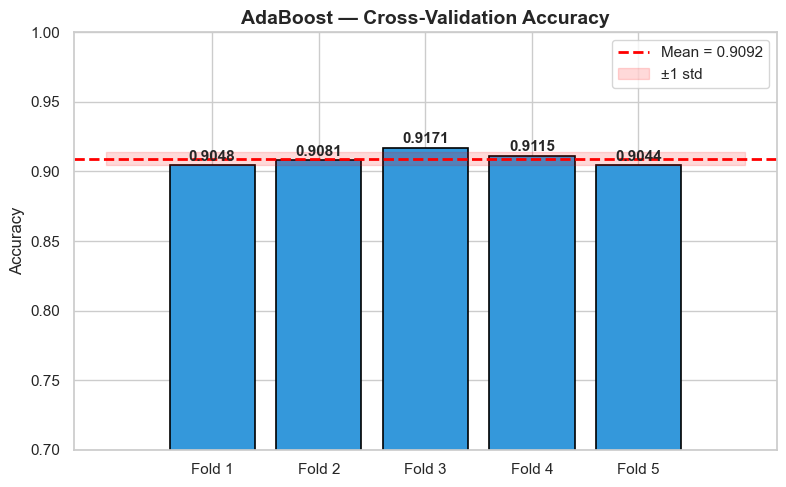

In [23]:
cv_scores = cross_val_score(ada_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print('='*60)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*60)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Mean  : {cv_scores.mean():.4f}')
print(f'  Std   : {cv_scores.std():.4f} (±{cv_scores.std() * 2:.4f})')

# Visualize CV scores
plt.figure(figsize=(8, 5))
bars = plt.bar([f'Fold {i}' for i in range(1, 6)], cv_scores,
               color='#3498db', edgecolor='black', linewidth=1.2)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.fill_between(range(-1, 6),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.15, color='red', label='±1 std')
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.003,
             f'{score:.4f}', ha='center', fontweight='bold')
plt.title('AdaBoost — Cross-Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Predictions and Evaluation

In [24]:
y_pred = ada_pipeline.predict(X_test)

ada_accuracy = accuracy_score(y_test, y_pred) * 100
ada_precision, ada_recall, ada_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted'
)

print('='*60)
print('ADABOOST — PERFORMANCE METRICS')
print('='*60)
print(f'Accuracy          : {ada_accuracy:.2f}%')
print(f'Precision (weighted): {ada_precision:.4f}')
print(f'Recall (weighted)   : {ada_recall:.4f}')
print(f'F1-Score (weighted) : {ada_f1:.4f}')
print(f'CV Mean Accuracy    : {cv_scores.mean():.4f}')
print(f'CV Std              : {cv_scores.std():.4f}')
print()
print('DETAILED CLASSIFICATION REPORT')
print('-'*60)
print(classification_report(y_test, y_pred))

ADABOOST — PERFORMANCE METRICS
Accuracy          : 90.53%
Precision (weighted): 0.9067
Recall (weighted)   : 0.9053
F1-Score (weighted) : 0.9057
CV Mean Accuracy    : 0.9092
CV Std              : 0.0047

DETAILED CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

      Cloudy       0.87      0.91      0.89       660
       Rainy       0.88      0.90      0.89       660
       Snowy       0.96      0.91      0.93       660
       Sunny       0.92      0.91      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



### 5.4 Confusion Matrix

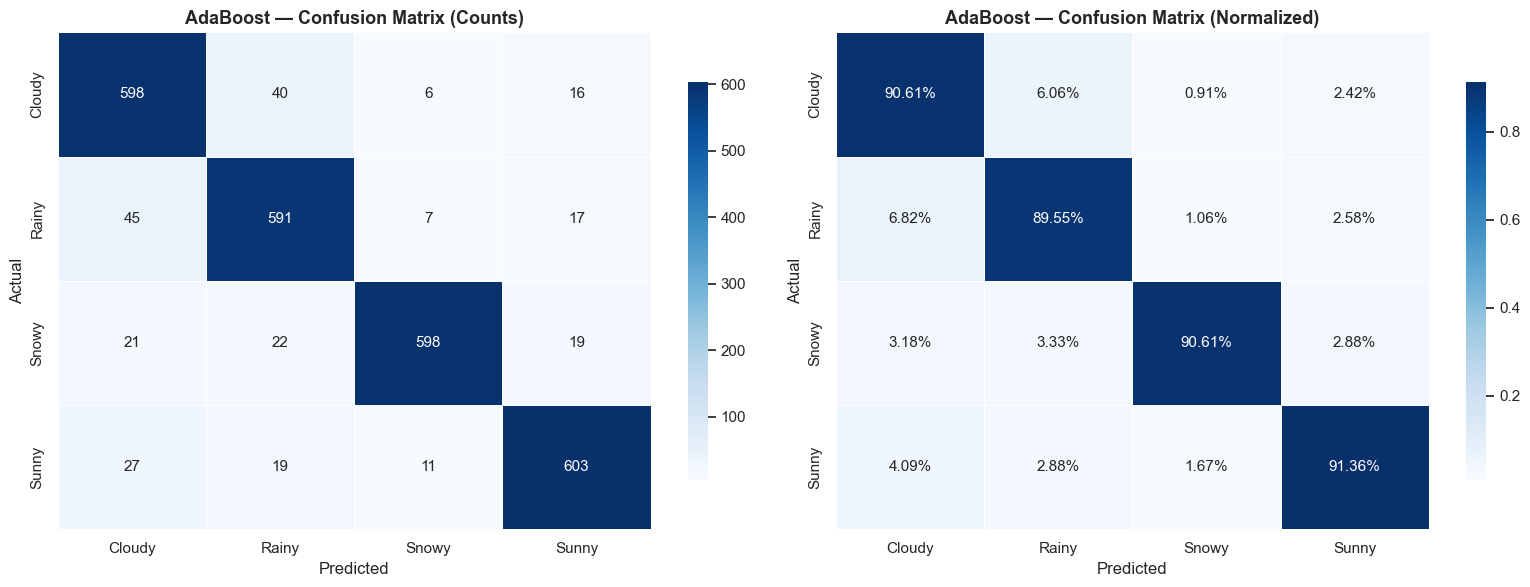

In [25]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted,
            ax=axes[0], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[0].set_title('AdaBoost — Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted,
            ax=axes[1], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[1].set_title('AdaBoost — Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

### 5.5 Misclassification Analysis

In [26]:
print('MISCLASSIFICATION ANALYSIS')
print('='*70)
total_errors = 0
for i, actual in enumerate(labels_sorted):
    for j, predicted in enumerate(labels_sorted):
        if i != j and cm[i][j] > 0:
            rate = (cm[i][j] / cm[i].sum()) * 100
            print(f'  {actual:<10} → {predicted:<10}: {cm[i][j]:>3} samples  ({rate:.2f}%)')
            total_errors += cm[i][j]

print(f'\n  Total misclassifications: {total_errors} / {len(y_test):,}')
print(f'  Overall error rate: {(total_errors / len(y_test)) * 100:.2f}%')

MISCLASSIFICATION ANALYSIS
  Cloudy     → Rainy     :  40 samples  (6.06%)
  Cloudy     → Snowy     :   6 samples  (0.91%)
  Cloudy     → Sunny     :  16 samples  (2.42%)
  Rainy      → Cloudy    :  45 samples  (6.82%)
  Rainy      → Snowy     :   7 samples  (1.06%)
  Rainy      → Sunny     :  17 samples  (2.58%)
  Snowy      → Cloudy    :  21 samples  (3.18%)
  Snowy      → Rainy     :  22 samples  (3.33%)
  Snowy      → Sunny     :  19 samples  (2.88%)
  Sunny      → Cloudy    :  27 samples  (4.09%)
  Sunny      → Rainy     :  19 samples  (2.88%)
  Sunny      → Snowy     :  11 samples  (1.67%)

  Total misclassifications: 250 / 2,640
  Overall error rate: 9.47%


### 5.6 Feature Importance

In [27]:
ada_model_fitted = ada_pipeline.named_steps['model']
feature_names = ada_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = ada_model_fitted.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('TOP 15 ADABOOST FEATURE IMPORTANCES')
print('='*50)
print(feat_imp_df.head(15).to_string(index=False))

TOP 15 ADABOOST FEATURE IMPORTANCES
                       Feature  Importance
     num__Atmospheric Pressure    0.235556
              num__Temperature    0.187945
               num__Wind Speed    0.142444
        num__Precipitation (%)    0.100637
          num__Visibility (km)    0.097962
        cat__Cloud Cover_clear    0.090950
                 num__UV Index    0.071236
     cat__Cloud Cover_overcast    0.038315
            cat__Season_Winter    0.012272
cat__Cloud Cover_partly cloudy    0.007138
       cat__Cloud Cover_cloudy    0.004195
            cat__Season_Summer    0.003034
        cat__Location_mountain    0.002788
            cat__Season_Autumn    0.001880
          cat__Location_inland    0.001623


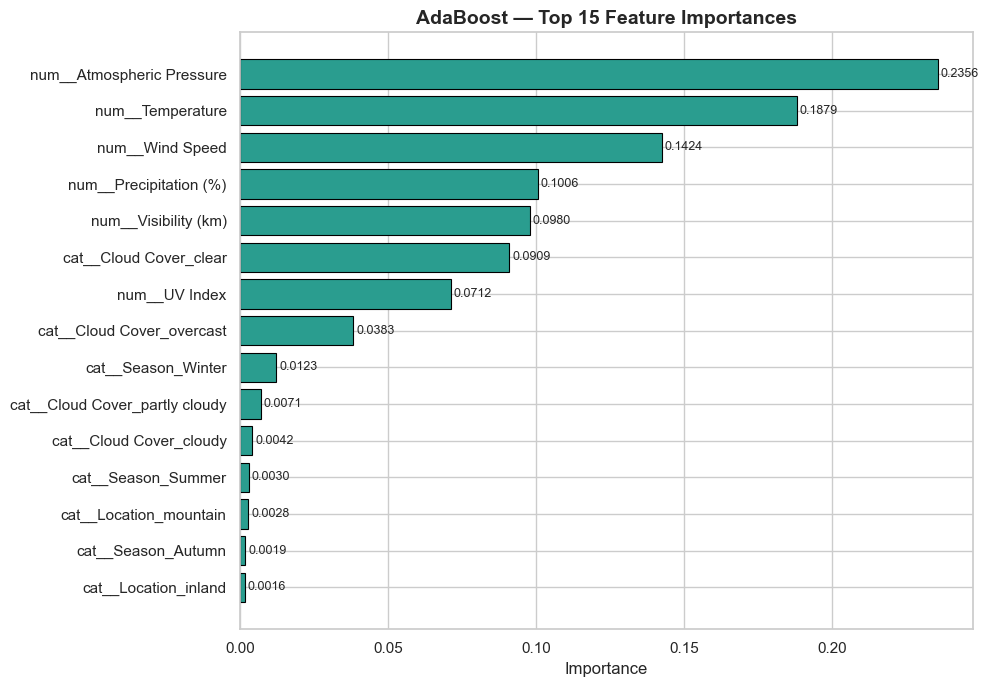

In [28]:
# Visualize feature importances
top_n = 15
top_feats = feat_imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
bars = plt.barh(top_feats['Feature'], top_feats['Importance'],
                color='#2a9d8f', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, top_feats['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.title(f'AdaBoost — Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

### 5.7 Learning Curve

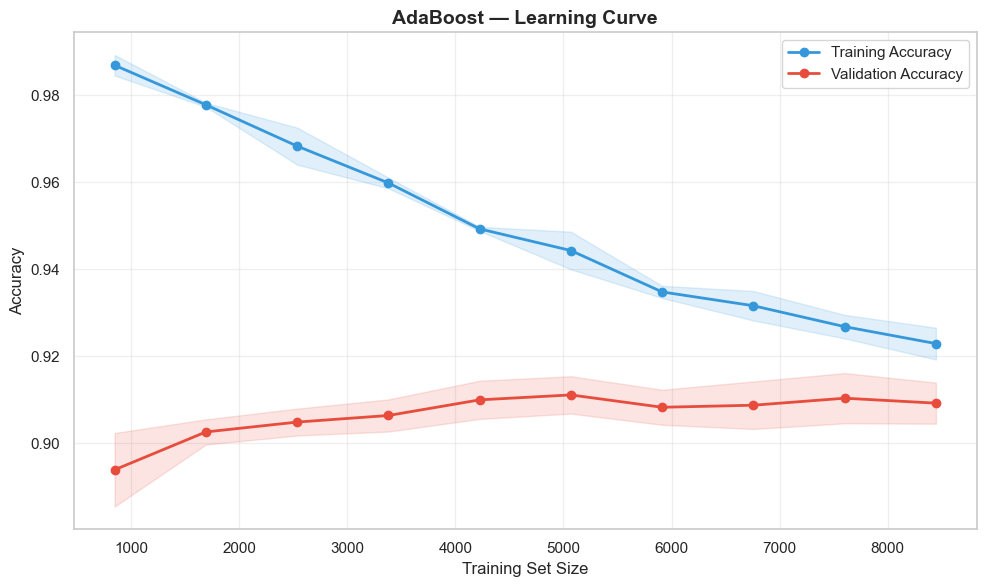

In [29]:
train_sizes, train_scores, val_scores = learning_curve(
    ada_pipeline, X_train, y_train,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3498db')
plt.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

plt.title('AdaBoost — Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8 Estimator Error Curve (Boosting Progression)

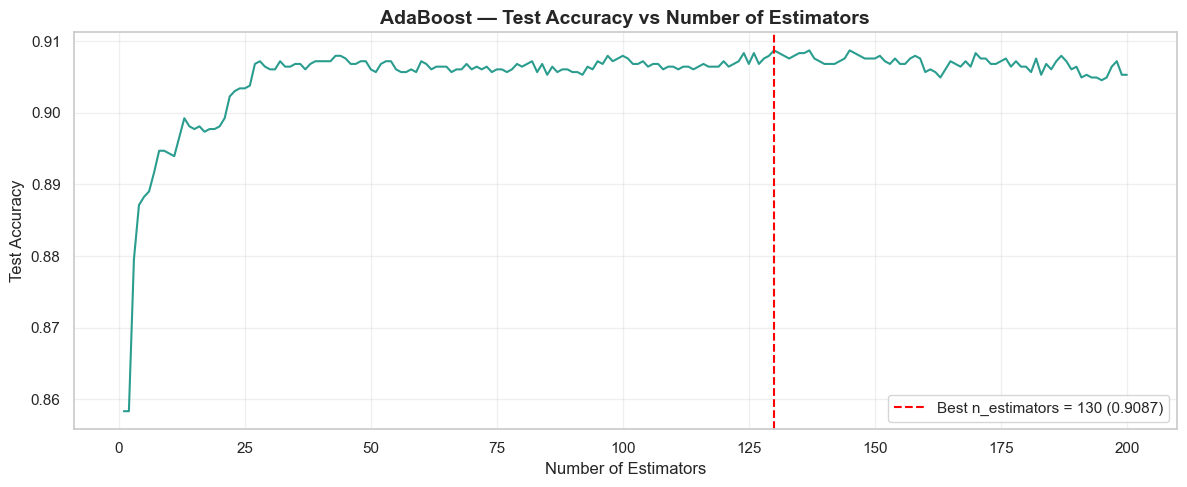


Best accuracy    : 0.9087  at n_estimators = 130


In [30]:
# Accuracy vs number of estimators (staged predictions)
X_test_preprocessed = ada_pipeline.named_steps['preprocessor'].transform(X_test)
staged_accuracies = [
    accuracy_score(y_test, pred)
    for pred in ada_model_fitted.staged_predict(X_test_preprocessed)
]

plt.figure(figsize=(12, 5))
plt.plot(range(1, len(staged_accuracies) + 1), staged_accuracies,
         color='#2a9d8f', linewidth=1.5)
best_n = np.argmax(staged_accuracies) + 1
plt.axvline(best_n, color='red', linestyle='--', linewidth=1.5,
            label=f'Best n_estimators = {best_n} ({max(staged_accuracies):.4f})')
plt.title('AdaBoost — Test Accuracy vs Number of Estimators', fontsize=14, fontweight='bold')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nBest accuracy    : {max(staged_accuracies):.4f}  at n_estimators = {best_n}')

## 6. Final Summary

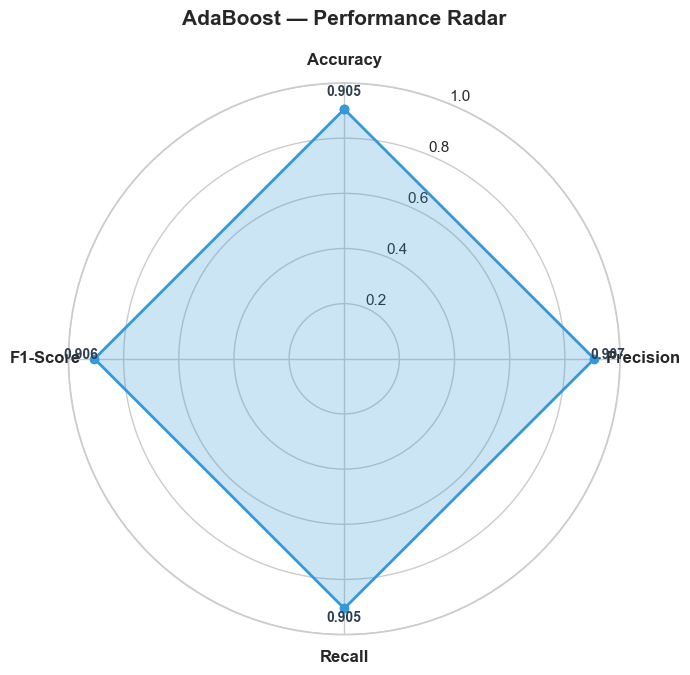

In [31]:
# ── Radar / spider chart ───────────────────────────────────────────
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [ada_accuracy / 100, ada_precision, ada_recall, ada_f1]
values += values[:1]
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='polar'))
ax.plot(angles, values, 'o-', linewidth=2, color='#3498db')
ax.fill(angles, values, alpha=0.25, color='#3498db')
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
for angle, val, label in zip(angles[:-1], values[:-1], categories):
    ax.text(angle, val + 0.05, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold', color='#2c3e50')
ax.set_title('AdaBoost — Performance Radar', size=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [32]:
# ── Final summary printout ─────────────────────────────────────────
print('='*80)
print('ADABOOST WEATHER CLASSIFICATION — EXECUTIVE SUMMARY')
print('='*80)

print(f"\n{'📊 DATASET':=^80}")
print(f"  Total samples     : {len(df):,}")
print(f"  Features          : {X.shape[1]} (meteorological & environmental)")
print(f"  Target classes    : 4 ({', '.join(labels_sorted)})")
print(f"  Training samples  : {X_train.shape[0]:,} (80%)")
print(f"  Testing samples   : {X_test.shape[0]:,} (20%)")

print(f"\n{'🤖 MODEL CONFIGURATION':=^80}")
print(f"  Algorithm         : AdaBoost (Adaptive Boosting)")
print(f"  Base estimator    : Decision Stump (max_depth=3)")
print(f"  N estimators      : 200")
print(f"  Learning rate     : 0.5")
print(f"  Preprocessing     : StandardScaler + OneHotEncoder (Pipeline)")

print(f"\n{'🏆 PERFORMANCE':=^80}")
print(f"  Test Accuracy     : {ada_accuracy:.2f}%")
print(f"  Precision         : {ada_precision:.4f}")
print(f"  Recall            : {ada_recall:.4f}")
print(f"  F1-Score          : {ada_f1:.4f}")
print(f"  CV Mean Accuracy  : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print(f"\n{'🔍 TOP 5 MOST IMPORTANT FEATURES':=^80}")
for i, row in feat_imp_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<35} Importance: {row['Importance']:.4f}")

print('='*80)

ADABOOST WEATHER CLASSIFICATION — EXECUTIVE SUMMARY

===================================📊 DATASET====================================
  Total samples     : 13,200
  Features          : 9 (meteorological & environmental)
  Target classes    : 4 (Cloudy, Rainy, Snowy, Sunny)
  Training samples  : 10,560 (80%)
  Testing samples   : 2,640 (20%)

=============================🤖 MODEL CONFIGURATION==============================
  Algorithm         : AdaBoost (Adaptive Boosting)
  Base estimator    : Decision Stump (max_depth=3)
  N estimators      : 200
  Learning rate     : 0.5
  Preprocessing     : StandardScaler + OneHotEncoder (Pipeline)

=================================🏆 PERFORMANCE==================================
  Test Accuracy     : 90.53%
  Precision         : 0.9067
  Recall            : 0.9053
  F1-Score          : 0.9057
  CV Mean Accuracy  : 0.9092 (±0.0047)

========================🔍 TOP 5 MOST IMPORTANT FEATURES=========================
  1. num__Atmospheric Pressure        